In [207]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [208]:
import logging
import os
import sys
from functools import partial

import matplotlib.pyplot as plt  # type: ignore
import numpy as np
from joblib import Parallel, delayed
from pixell import curvedsky
from tqdm.auto import tqdm

from scripts import core, Core
from scripts.utils import (
    remove_mono_dipole,
    setup_logging,
    plot_cl_alm,
    plot_patches,
    plot_predictions,
)

from notebooks.ksw_joblib import KSW_joblib

# Monkey patch the core module
core.KSW = KSW_joblib

In [209]:
logger = setup_logging(__name__, level=logging.DEBUG)

## Setup

In [210]:
core = Core(
    [
        "settings/l256_n64.json",
        "--nsims",
        "100",
        "--narray",
        "1",
        "--no-noise",
        # "--lensing",
        # "--polarizations",
        # "TE",
    ]
)

09-Jun-24 12:16:23 - scripts.core - DEBUG - Parsing CLI args: ['settings/l256_n64.json', '--nsims', '100', '--narray', '1', '--no-noise']
09-Jun-24 12:16:23 - scripts.core - INFO - Loading settings from file settings/l256_n64.json
09-Jun-24 12:16:23 - scripts.core - DEBUG - Forcing setting 'nsims' to '100' due to CLI
09-Jun-24 12:16:23 - scripts.core - DEBUG - Forcing setting 'narray' to '1' due to CLI
09-Jun-24 12:16:23 - scripts.core - DEBUG - Forcing setting 'noise' to 'False' due to CLI
09-Jun-24 12:16:23 - scripts.core - DEBUG - Found non-default value for 'cosmo_params': {'H0': 67.4, 'As': 2.457e-09, 'ns': 0.9649, 'ombh2': 0.0224, 'omch2': 0.12, 'tau': 0.054, 'max_l': 500, 'lmax': 256} (default: {'As': 2.13e-09, 'ns': 0.9624, 'pivot_scalar': 0.05, 'max_l': 1000, 'lmax': 500})
09-Jun-24 12:16:23 - scripts.core - DEBUG - Overriding cosmo param As from 2.13e-09 to 2.457e-09
09-Jun-24 12:16:23 - scripts.core - DEBUG - Overriding cosmo param ns from 0.9624 to 0.9649
09-Jun-24 12:16:23

## Alm

This code generates the alms

$$a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}^{NG}$$
with
$$a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]$$
and
$$\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)$$
$$\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)$$
$$B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}$$
where $\Delta_\phi$ is primordial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions   

In [211]:
from scripts.almgen import generate_alm_ng

In [212]:
alm_l = np.array(
    [core.data.compute_alm_sim(core.lensing) for _ in range(core.nsims)],
    dtype=core.c_dtype,
)

fnls = core.rng.uniform(core.fnl_min, core.fnl_max, core.fnl_shape)

alm_ng = generate_alm_ng(core, alm_l)

alms = alm_l + fnls[:, None, :] * alm_ng
alms = remove_mono_dipole(alms)

09-Jun-24 12:16:37 - scripts.almgen - INFO - Starting Alm_ng generation
09-Jun-24 12:16:37 - scripts.almgen - DEBUG - Using temp folder for Alm_ng generation: /lustre/scratch/client/users/stevensonb


Alm_ng:   0%|          | 0/100 [00:00<?, ?it/s]

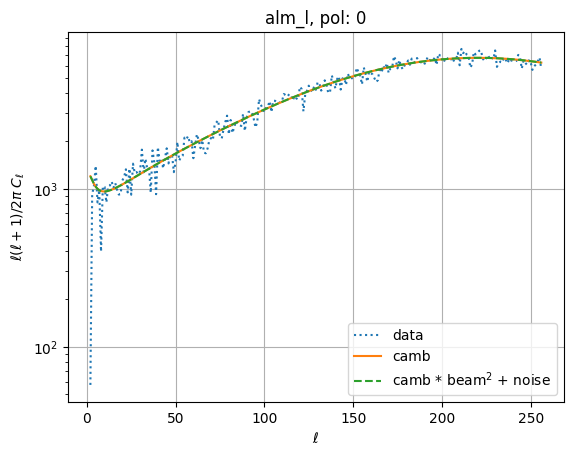

In [213]:
for pol in range(core.npol):
    plot_cl_alm(
        alm_l[0, pol],
        title=f"alm_l, pol: {pol}",
        plot_camb=True,
        c_ells=core.c_ells[:, pol],
        camb_noise=True,
        noise=core.noise_ell[pol],
        beam_width=core.beam_width,
    )

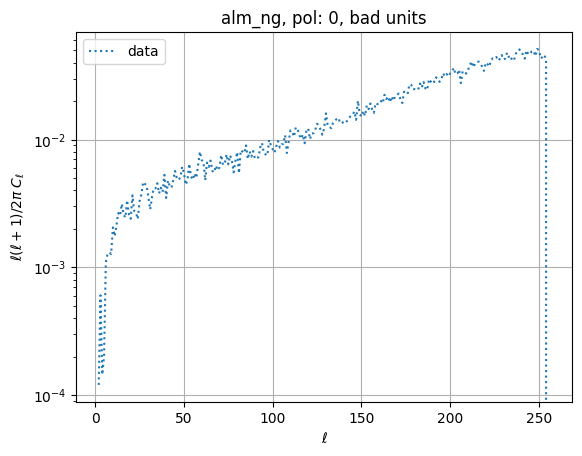

In [214]:
for pol in range(core.npol):
    plot_cl_alm(alm_ng[0, pol], title=f"alm_ng, pol: {pol}, bad units")

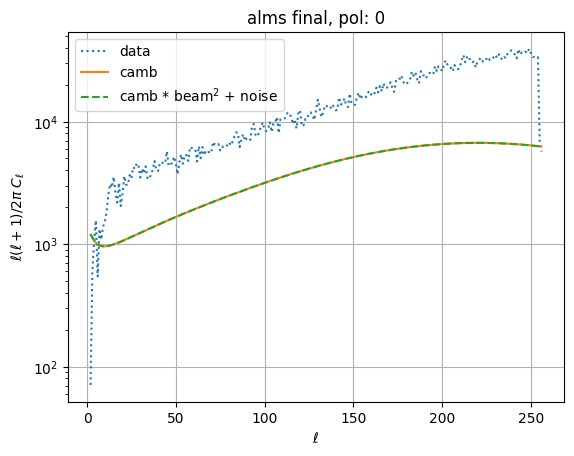

In [215]:
for pol in range(core.npol):
    plot_cl_alm(
        alms[0, pol],
        title=f"alms final, pol: {pol}",
        plot_camb=True,
        c_ells=core.c_ells[:, pol],
        camb_noise=True,
        noise=core.noise_ell[pol],
        beam_width=core.beam_width,
    )

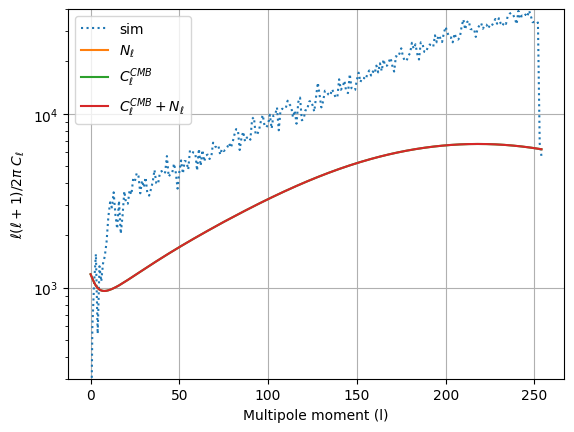

In [216]:
for pol in range(core.npol):
    ells = np.arange(2, core.nell)
    scale = ells * (ells + 1) / 2 / np.pi
    N_ell = core.noise_ell[pol, 2:]
    cl_cmb = core.c_ells[2 : core.nell, pol]
    cl_sim = curvedsky.alm2cl(alms[0, pol])[2 : core.nell]
    beam = core.beam_ell[pol, 2:]

    plot_func = plt.semilogy
    plot_func(scale * cl_sim, label=r"sim", linestyle=":")
    plot_func(scale * N_ell, label=r"$N_\ell$")
    plot_func(scale * cl_cmb, label=r"$C_{\ell}^{CMB}$")
    plot_func(scale * (cl_cmb * beam**2 + N_ell), label=r"$C_\ell^{CMB} + N_\ell$")

    plt.legend()
    plt.xlabel("Multipole moment (l)")
    plt.ylabel(r"$\ell(\ell+1)/2\pi\;C_{\ell}$")
    plt.grid(True)
    if pol == 0:
        plt.ylim([3e2, 4e4])
    if pol == 1:
        plt.ylim([1e-3, 1e2])
    plt.show()

## PatchGen

In [217]:
# from scripts.patchgen import cutSqPatches_lenspyx, cutSqPatches_pixell, get_fs_patch_geo

In [218]:
# # Here we get the geometry of our patches in a tuple
# patch_geo = get_fs_patch_geo(core)

# # We use joblib.parallel to generate the patches in parallel
# # by default (temp_folder=None) this will use a ram disk /dev/shm
# # if the data files are larger than the available memory, about 1TB, it will error
# # so we give it a temp folder to use, which wont have that problem
# temp_folder = os.environ.get("SCRATCH", None)
# logger.debug(f"Using temp folder for patch generation: {temp_folder}")
# parallel = Parallel(n_jobs=1, return_as="generator", temp_folder=temp_folder)

# # we also setup the cutPatches function to use either pixell or lenspyx
# # depending on if we are doing lensing or not, and provide a lot of
# # arguments that are needed and will stay constant
# # we cannot abuse the python scope here since these will need to be pickled
# common_settings = [
#     core.lmax,
#     core.plot_dir,
#     core.base_name,
#     core.npatches,
#     core.c_ells,
#     *patch_geo,
# ]
# if core.lensing:
#     max_l = core.cosmo_params["max_l"]
#     cl_phi = core.cosmo._camb_data.get_lens_potential_cls(  # type: ignore
#         max_l, CMB_unit="muK", raw_cl=True
#     )

#     cutPatches = partial(
#         cutSqPatches_lenspyx, *common_settings, max_l, core.nside, core.r_dtype
#     )

#     patch_generator = parallel(
#         delayed(cutPatches)(alms[sim], fnls[sim], cl_phi[:, 0], True)
#         for sim in range(core.nsims)
#     )  # CL_PHI is in PP, PT, PE order, we only use the PP
# else:
#     cutPatches = partial(cutSqPatches_pixell, *common_settings)

#     patch_generator = parallel(
#         delayed(cutPatches)(alms[sim], fnls[sim], True) for sim in range(core.nsims)
#     )

# # create the array to store the patches
# patches = np.empty(core.patch_shape, dtype=core.r_dtype)

# # Get our data from the generator
# for idx, result in enumerate(
#     tqdm(patch_generator, desc="patch progress", total=core.nsims)
# ):
#     patches[idx] = result

In [219]:
# for pol in range(core.npol):
#     plot_patches(patches[0, pol], 10, title=f"Pol {pol}")

## Estimator

In [220]:
mc_path = os.path.join(core.base_dir, "kswmc")
os.makedirs(mc_path, exist_ok=True)
mc_file = os.path.join(mc_path, f"{core.base_name}.hdf5")

# uncomment to remove the mc file to regenerated
if os.path.exists(mc_file):
    os.remove(mc_file)

theta_batch = int(np.floor(1.5 * core.lmax + 1)) // len(os.sched_getaffinity(0))

if os.path.exists(mc_file):
    logger.info("Loading KSW state from %s", mc_file)
    core.ksw.start_from_read_state(mc_file, None)
else:

    def alm_step_loader(idx):
        return core.data.compute_alm_sim(core.lensing)

    core.ksw.step_batch(alm_step_loader, range(100), theta_batch=theta_batch)

    logger.info("Saving KSW state to %s", mc_file)
    core.ksw.write_state(mc_file)

09-Jun-24 12:19:53 - notebooks.ksw_joblib - INFO - processing 0
09-Jun-24 12:19:54 - notebooks.ksw_joblib - INFO - processing 1
09-Jun-24 12:19:54 - notebooks.ksw_joblib - INFO - processing 2
09-Jun-24 12:19:55 - notebooks.ksw_joblib - INFO - processing 3
09-Jun-24 12:19:55 - notebooks.ksw_joblib - INFO - processing 4
09-Jun-24 12:19:56 - notebooks.ksw_joblib - INFO - processing 5
09-Jun-24 12:19:56 - notebooks.ksw_joblib - INFO - processing 6
09-Jun-24 12:19:56 - notebooks.ksw_joblib - INFO - processing 7
09-Jun-24 12:19:57 - notebooks.ksw_joblib - INFO - processing 8
09-Jun-24 12:19:57 - notebooks.ksw_joblib - INFO - processing 9
09-Jun-24 12:19:58 - notebooks.ksw_joblib - INFO - processing 10
09-Jun-24 12:19:58 - notebooks.ksw_joblib - INFO - processing 11
09-Jun-24 12:19:59 - notebooks.ksw_joblib - INFO - processing 12
09-Jun-24 12:19:59 - notebooks.ksw_joblib - INFO - processing 13
09-Jun-24 12:20:00 - notebooks.ksw_joblib - INFO - processing 14
09-Jun-24 12:20:00 - notebooks.ksw_

In [221]:
fisher = float(core.ksw.compute_fisher())  # / core.npol
logger.info("Fisher: %s, standard deviation: %s", fisher, np.sqrt(1 / fisher))

09-Jun-24 12:20:42 - __main__ - INFO - Fisher: 0.0009747076078220592, standard deviation: 32.03043391516504


In [222]:
def alm_loader(i):
    logger.info("Loading alm %s, FNL %s", i, fnls[i])
    return alms[i]


idxs = range(alms.shape[0])

estimates = core.ksw.compute_estimate_batch(
    alm_loader, idxs, theta_batch=theta_batch, fisher=fisher
)

09-Jun-24 12:20:42 - __main__ - INFO - Loading alm 0, FNL [787.8350921]
09-Jun-24 12:20:42 - notebooks.ksw_joblib - DEBUG - t_cubic: 29.13147710715566, lin_term: 0.009791053417766727, fisher: 0.0009747076078220592
09-Jun-24 12:20:42 - notebooks.ksw_joblib - INFO - estimate: 29877.35585526926
09-Jun-24 12:20:42 - __main__ - INFO - Loading alm 1, FNL [974.10301979]
09-Jun-24 12:20:43 - notebooks.ksw_joblib - DEBUG - t_cubic: 41.470241428818554, lin_term: 0.00883069507991677, fisher: 0.0009747076078220592
09-Jun-24 12:20:43 - notebooks.ksw_joblib - INFO - estimate: 42537.28030950976
09-Jun-24 12:20:43 - __main__ - INFO - Loading alm 2, FNL [973.28966839]
09-Jun-24 12:20:43 - notebooks.ksw_joblib - DEBUG - t_cubic: 92.53635501954705, lin_term: 0.0011408012416005199, fisher: 0.0009747076078220592
09-Jun-24 12:20:43 - notebooks.ksw_joblib - INFO - estimate: 94936.38243480142
09-Jun-24 12:20:43 - __main__ - INFO - Loading alm 3, FNL [232.59105876]
09-Jun-24 12:20:43 - notebooks.ksw_joblib - D

09-Jun-24 12:21:12 - scripts.utils.plots - DEBUG - Plotting with standard deviation: 32.03043391516504


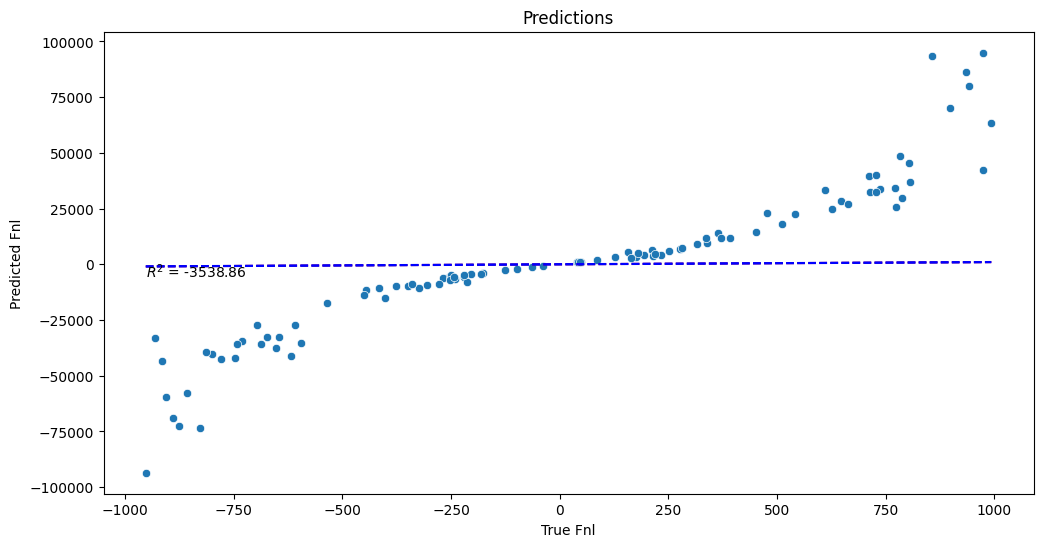

In [223]:
plot_predictions(fnls, estimates, fisher=fisher)

# Estimator testor

In [224]:
def compute_iso_icov(N, b):
    # Inverse covariance matrix diagonal in ell. Unlike "icov" this should be: 1 / (S_ell + (b^{-1} N b^{-1})_ell)
    S_ell = core.cosmo._camb_data.get_cmb_power_spectra(
        core.cosmo.camb_params, core.lmax, ["total"], "muK", True
    )["total"]
    print(S_ell.shape)
    S_ell = np.transpose(S_ell, (1, 0))[: core.npol]
    print(S_ell.shape)
    b_inv = 1 / b
    print(np.shape(b_inv), np.shape(N))
    return 1 / (S_ell + b_inv * N * b_inv)


icov_ell = compute_iso_icov(core.noise_ell[: core.npol], core.beam_ell)
fisher_iso = core.ksw.compute_fisher_isotropic(icov_ell)
N_fact = core.cosmo.red_bispectra[0].nfact
print(fisher_iso, N_fact, fisher / fisher_iso)

(257, 4)
(1, 257)
(1, 257) (1, 257)
0.0010046879 1200 0.970159635586356
